In [17]:
# Cross Validation - Missing Values Example بالعربي || Machine Learning #28
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


titanic = pd.read_csv('train.csv')
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(titanic, test_size=0.3, random_state=42)
print(train_data.shape)
print("*=" * 15)
print(test_data.shape)
print("*=" * 15)
display(titanic)


(623, 12)
*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=
(268, 12)
*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [18]:
str_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = train_data.drop('Survived', axis='columns')
y = train_data['Survived']

In [19]:
scores = []
for train_idx, val_idx in str_kfold.split(X, y):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    X_train_fold['Age'].fillna(X_train_fold['Age'].median(), inplace=True)
    X_val_fold['Age'].fillna(X_val_fold['Age'].median(), inplace=True)

    X_train_fold['Cabin'].fillna("Unknown", inplace=True)
    X_val_fold['Cabin'].fillna("Unknown", inplace=True)

    most_freq = X_train_fold['Embarked'].mode()[0]

    X_train_fold['Embarked'].fillna(most_freq, inplace=True)
    X_val_fold['Embarked'].fillna(most_freq, inplace=True)

    X_train_fold = X_train_fold[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
    X_val_fold = X_val_fold[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_fold, y_train_fold)

    y_pred = model.predict(X_val_fold)

    accuracy = accuracy_score(y_val_fold, y_pred)
    scores.append(accuracy)

C:\Users\djabe\AppData\Local\Temp\ipykernel_2768\293872928.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train_fold['Age'].fillna(X_train_fold['Age'].median(), inplace=True)
C:\Users\djabe\AppData\Local\Temp\ipykernel_2768\293872928.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_fold['Age'].fillna(X_train_fold['Age'].media

In [20]:
avg_accuracy = np.mean(scores)


In [21]:
# Categoriel Encoding

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()



In [22]:
train_data['Sex']

445      male
650      male
172    female
450      male
314      male
        ...  
106    female
270      male
860      male
435    female
102      male
Name: Sex, Length: 623, dtype: object

In [23]:
train_data['Sex'] = label_encoder.fit_transform(train_data['Sex'])
test_data['Sex'] = label_encoder.transform(test_data['Sex']) 
# في المرة الثانية دير transform باش تضمن بلي التقسيم يكون نفسو male =1 , female =0 !!


In [24]:
display(train_data)
print("*=" * 69)
display(test_data)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
445,446,1,1,"Dodge, Master. Washington",1,4.0,0,2,33638,81.8583,A34,S
650,651,0,3,"Mitkoff, Mr. Mito",1,NaN,0,0,349221,7.8958,NaN,S
172,173,1,3,"Johnson, Miss. Eleanor Ileen",0,1.0,1,1,347742,11.1333,NaN,S
450,451,0,2,"West, Mr. Edwy Arthur",1,36.0,1,2,C.A. 34651,27.7500,NaN,S
314,315,0,2,"Hart, Mr. Benjamin",1,43.0,1,1,F.C.C. 13529,26.2500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
106,107,1,3,"Salkjelsvik, Miss. Anna Kristine",0,21.0,0,0,343120,7.6500,NaN,S
270,271,0,1,"Cairns, Mr. Alexander",1,NaN,0,0,113798,31.0000,NaN,S
860,861,0,3,"Hansen, Mr. Claus Peter",1,41.0,2,0,350026,14.1083,NaN,S
435,436,1,1,"Carter, Miss. Lucile Polk",0,14.0,1,2,113760,120.0000,B96 B98,S


*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",1,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",1,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",1,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",0,6.0,0,1,248727,33.0000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",0,14.0,1,0,2651,11.2417,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...,...
821,822,1,3,"Lulic, Mr. Nikola",1,27.0,0,0,315098,8.6625,NaN,S
633,634,0,1,"Parr, Mr. William Henry Marsh",1,NaN,0,0,112052,0.0000,NaN,S
456,457,0,1,"Millet, Mr. Francis Davis",1,65.0,0,0,13509,26.5500,E38,S
500,501,0,3,"Calic, Mr. Petar",1,17.0,0,0,315086,8.6625,NaN,S


In [25]:
# metode of One hot Encoding

from sklearn.preprocessing import OneHotEncoder

hot_encode = OneHotEncoder(sparse_output =False) # sparse t5li masfofa monadama fiha 0 et 1 !!

hot_encode.fit_transform(train_data[['Embarked']])



array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.]], shape=(623, 4))

In [26]:
display(train_data[['Embarked']].value_counts())

Embarked
S           457
C           110
Q            55
Name: count, dtype: int64

In [27]:
hot_encode_df = pd.DataFrame(hot_encode, columns=hot_encode.get_feature_names_out(['Embarked']), index = train_data.index)

train_data = pd.concat([train_data, hot_encode_df], axis=1)
display(train_data.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
445,446,1,1,"Dodge, Master. Washington",1,4.0,0,2,33638,81.8583,A34,S,OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False)
650,651,0,3,"Mitkoff, Mr. Mito",1,NaN,0,0,349221,7.8958,NaN,S,OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False)
172,173,1,3,"Johnson, Miss. Eleanor Ileen",0,1.0,1,1,347742,11.1333,NaN,S,OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False)
450,451,0,2,"West, Mr. Edwy Arthur",1,36.0,1,2,C.A. 34651,27.7500,NaN,S,OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False)
314,315,0,2,"Hart, Mr. Benjamin",1,43.0,1,1,F.C.C. 13529,26.2500,NaN,S,OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False)


In [28]:
test_data = pd.concat([test_data, hot_encode_df], axis=1)
display(test_data.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
709,710.0,1.0,3.0,"Moubarek, Master. Halim Gonios (""William George"")",1.0,NaN,1.0,1.0,2661,15.2458,NaN,C,NaN,NaN,NaN,NaN
439,440.0,0.0,2.0,"Kvillner, Mr. Johan Henrik Johannesson",1.0,31.0,0.0,0.0,C.A. 18723,10.5000,NaN,S,NaN,NaN,NaN,NaN
840,841.0,0.0,3.0,"Alhomaki, Mr. Ilmari Rudolf",1.0,20.0,0.0,0.0,SOTON/O2 3101287,7.9250,NaN,S,NaN,NaN,NaN,NaN
720,721.0,1.0,2.0,"Harper, Miss. Annie Jessie ""Nina""",0.0,6.0,0.0,1.0,248727,33.0000,NaN,S,NaN,NaN,NaN,NaN
39,40.0,1.0,3.0,"Nicola-Yarred, Miss. Jamila",0.0,14.0,1.0,0.0,2651,11.2417,NaN,C,NaN,NaN,NaN,NaN



               Categorical Encoding: Ordinal, Frequency, and Mean Encoding Explained #2 بالعربية || ML#29

Oridinal Encoding

In [29]:
embarked_map = {'S':0, 'C':1,'Q':2}

train_data['Embarked_Ordinal'] = train_data['Embarked'].map(embarked_map) # add new columns !!

display(train_data[:5])

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan,Embarked_Ordinal
445,446,1,1,"Dodge, Master. Washington",1,4.0,0,2,33638,81.8583,A34,S,OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),0.0
650,651,0,3,"Mitkoff, Mr. Mito",1,NaN,0,0,349221,7.8958,NaN,S,OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),0.0
172,173,1,3,"Johnson, Miss. Eleanor Ileen",0,1.0,1,1,347742,11.1333,NaN,S,OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),0.0
450,451,0,2,"West, Mr. Edwy Arthur",1,36.0,1,2,C.A. 34651,27.7500,NaN,S,OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),0.0
314,315,0,2,"Hart, Mr. Benjamin",1,43.0,1,1,F.C.C. 13529,26.2500,NaN,S,OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),OneHotEncoder(sparse_output=False),0.0


In [30]:
# low:0, medium:1, average:1, high:2  

Count Encoding

Mean Encoding

Categorical Encoding with Cross Validation بالعربية || Machine Learning #30

In [31]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_data, test_data = train_test_split(titanic, test_size=0.3, random_state=42)
X = train_data.drop('Survived', axis='columns')
y = train_data['Survived']
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
scores = []

onehot_encoder = OneHotEncoder(sparse_output =False)
label_encoder = LabelEncoder()

for train_index, val_index in strat_kfold.split(X, y):
  X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
  y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
  
  X_train_fold['Age'].fillna(X_train_fold['Age'].median(), inplace=True)
  X_val_fold['Age'].fillna(X_train_fold['Age'].median(), inplace=True)
  
  X_train_fold['Cabin'].fillna('Unknown', inplace=True)
  X_val_fold['Cabin'].fillna('Unknown', inplace=True)
  
  most_frequent_embarked_fold = X_train_fold['Embarked'].mode()[0]
  X_train_fold['Embarked'].fillna(most_frequent_embarked_fold, inplace=True)
  X_val_fold['Embarked'].fillna(most_frequent_embarked_fold, inplace=True)
  
  # X_train_fold = X_train_fold[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex', 'Embarked', 'Cabin']]
  # X_val_fold = X_val_fold[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex', 'Embarked', 'Cabin']]
  
  sex_encoded_train = onehot_encoder.fit_transform(X_train_fold[['Sex']])
  sex_encoded_val = onehot_encoder.transform(X_val_fold[['Sex']])
    
  temp_df = X_train_fold.copy()
  temp_df['Survived'] = y_train_fold  
  embarked_mean_encoding = temp_df.groupby('Embarked')['Survived'].mean().to_dict()
  embarked_encoded_train = X_train_fold['Embarked'].map(embarked_mean_encoding)
  embarked_encoded_val = X_val_fold['Embarked'].map(embarked_mean_encoding)
  del temp_df
  
  label_encoder.fit(pd.concat([X_train_fold['Cabin'], X_val_fold['Cabin']]))
  cabin_encoded_train = label_encoder.transform(X_train_fold['Cabin'])
  cabin_encoded_val = label_encoder.transform(X_val_fold['Cabin'])
  
  columns = ['Sex_encoded_' + str(i) for i in range(sex_encoded_train.shape[1])]
  
  
  
  X_train_fold = X_train_fold[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
  # X_train_fold['Sex_encoded'] = sex_encoded_train
  X_train_fold['Embarked_encoded'] = embarked_encoded_train
  X_train_fold['Cabin_encoded'] = cabin_encoded_train
  
  X_val_fold = X_val_fold[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
  # X_val_fold['Sex_encoded'] = sex_encoded_val
  X_val_fold['Embarked_encoded'] = embarked_encoded_val
  X_val_fold['Cabin_encoded'] = cabin_encoded_val
  
  for i, col in enumerate(columns):
    X_train_fold[col] = sex_encoded_train[:, i]
    X_val_fold[col] = sex_encoded_val[:, i]
    
  model = LogisticRegression(max_iter=1000)
  model.fit(X_train_fold, y_train_fold)
  
  y_pred = model.predict(X_val_fold)
  
  accuracy = accuracy_score(y_val_fold, y_pred)
  
  scores.append(accuracy)

C:\Users\djabe\AppData\Local\Temp\ipykernel_2768\2385168721.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train_fold['Age'].fillna(X_train_fold['Age'].median(), inplace=True)
C:\Users\djabe\AppData\Local\Temp\ipykernel_2768\2385168721.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_fold['Age'].fillna(X_train_fold['Age'].m


Feature Scaling Scikit-learn || Min-Max scaling | Standardization بالعربية

Min Max Scaling
$$x_j'^{(i)} = \frac{x_j^{(i)} - \min(x_j)}{\max(x_j) - \min(x_j)}$$

Standard Scaling !
$$x_j'^{(i)} = \frac{x_j^{(i)} - \mu(x_j)}{\sigma(x_j)}$$

In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# MinMaxScalar !!!


MAE, MSE, RMSE, R2 score - Evaluation Metrics for Regression #32 - بالعربي

Mean Absolute Value
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

Mean Squared Error
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Root Mean Squared Error
$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

R-squared (Coefficient of Determination)
$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

Confusion Matrix #33 !!

$$Accuracy = \frac{Number  of  correct  predictions}{ Total  number  of  predictions}$$

'Thr accuracy is :  75.0% '

Text(50.722222222222214, 0.5, 'y_True')

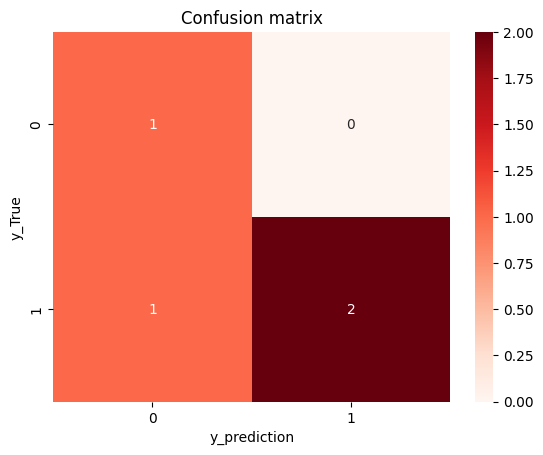

In [53]:
from sklearn.metrics import accuracy_score
import seaborn as sns
y_true = [1,0,1,1]
y_pred = [1,0,1,0]

accuracy = accuracy_score(y_true, y_pred)
display(f"Thr accuracy is :  {accuracy*100}% ")

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')

plt.title("Confusion matrix")
plt.xlabel("y_prediction")
plt.ylabel("y_True")


Precision, Recall, F1 score, F-beta score Metrics - بالعربية

Precision
$$Precision = \frac{TP}{TP + FP}$$

Recal
$$Recall =  \frac{TP}{TP + FN}

F1 Score
$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

F-beta Score
$$F_{\beta} = (1 + \beta^2) \times \frac{Precision \times Recall}{(\beta^2 \times Precision) + Recall}$$


ROC Curve, AUC Score & PR Curve Explained || بالعربية

roc w auc مشفتهمش راني ؟؟